In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install owlready2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 45.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for owlready2: filename=owlready2-0.51-cp313-cp313-linux_x86_64.whl size=24764661 sha256=1dc3b76574ca5ee44ed9c3d08d11dffccdce36d64588fffdd005a9906cd6c61f
  Stored in directory: /root/.cache/pip/wheels/cc/16/52/762fdfa8c53f256db44674790a3ceba702c3c763c96ce8b62c
Successfully built owlready2


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import owlready2 as or2

In [ ]:
onto = or2.get_ontology("/path/to/ontology/mlprov.owx").load()
with onto:
    class description(or2.DataProperty):
        range = [str]

* Owlready2 * WARNING: ObjectProperty http://www.w3.org/ns/prov#wasRevisionOf belongs to more than one entity types: [owl.AnnotationProperty, owl.ObjectProperty, prov.wasDerivedFrom]; I'm trying to fix it...
* Owlready2 * WARNING: ObjectProperty http://www.w3.org/ns/prov#specializationOf belongs to more than one entity types: [owl.AnnotationProperty, owl.ObjectProperty, prov.alternateOf]; I'm trying to fix it...


In [5]:
train_data = onto["training_dataset"]
test_data = onto["testing_dataset"]
onto_model = onto["model"]
performance_metric = onto["performance_metric"]
pred_log = onto["prediction"]

In [6]:
# 1. Generate the dataset
X, y = make_moons(n_samples=300, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
train_data_matrix = np.column_stack((X_train, y_train))
np.savetxt('/path/to/data/train.csv', train_data_matrix, delimiter=',', header='x1,x2,y', comments='')

test_data_matrix = np.column_stack((X_test, y_test))
np.savetxt('/path/to/data/test.csv', test_data_matrix, delimiter=',', header='x1,x2,y', comments='')

In [8]:
training_dataset = train_data("train.csv")
training_dataset.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]
testing_dataset = test_data("test.csv")
testing_dataset.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]

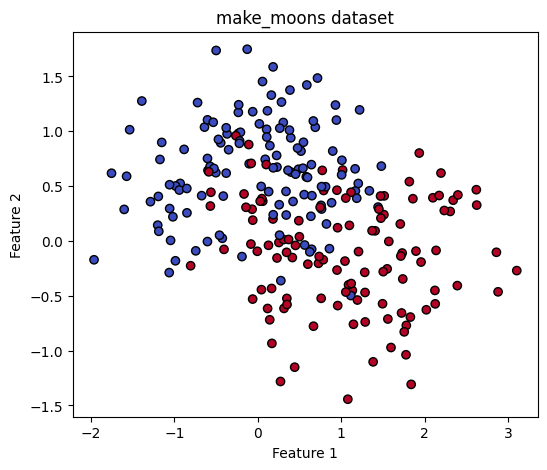

In [9]:
# 2. Visualize the raw data
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolors="k")
plt.title("make_moons dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# Linear

In [10]:
# 3. Fit a linear SVM vs. an RBF SVM
linear_svm = SVC(kernel="linear").fit(X_train, y_train)
model = onto_model("linear_svm")
model.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]

In [11]:
# 4. Helper to plot decision boundaries
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")



In [12]:
y_pred_lin = linear_svm.predict(X_test)

np.savetxt('/content/drive/MyDrive/2026-2027/Bias/estimator/lin_pred_log.csv', y_pred_lin, delimiter=',', header='y', comments='')
lin_pred_log = pred_log("lin_pred_log.csv")
lin_pred_log.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]

acc_lin = accuracy_score(y_test, y_pred_lin)
print(f"Accuracy for linear SVM: {acc_lin}")
linear_acc = performance_metric(f"Linear_accuracy={acc_lin}")


prec_lin = precision_score(y_test, y_pred_lin)
print(f"Precision for linear SVM: {prec_lin}")
linear_prec = performance_metric(f"Linear_precision={prec_lin}")


rec_lin = recall_score(y_test, y_pred_lin)
print(f"Recall for linear SVM: {rec_lin}")
linear_rec = performance_metric(f"Linear_recall={rec_lin}")


f1_lin = f1_score(y_test, y_pred_lin)
print(f"F1 score for linear SVM: {f1_lin}")
linear_f1 = performance_metric(f"Linear_f1={f1_lin}")

Accuracy for linear SVM: 0.8333333333333334
Precision for linear SVM: 0.8333333333333334
Recall for linear SVM: 0.8823529411764706
F1 score for linear SVM: 0.8571428571428571


# RBF Kernel

In [13]:
rbf_svm = SVC(kernel="rbf", gamma=2).fit(X_train, y_train)
model = onto_model("rbf_svm")
model.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]

In [14]:
y_pred_rbf = rbf_svm.predict(X_test)

np.savetxt('/content/drive/MyDrive/2026-2027/Bias/estimator/rbf_pred_log.csv', y_pred_rbf, delimiter=',', header='y', comments='')
rbf_pred_log = pred_log("rbf_pred_log.csv")
rbf_pred_log.description = ["Location: https://github.com/AnonymousWriter1/BiasProvenance"]

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy for RBF SVM: {acc_rbf}")
rbf_acc = performance_metric(f"RBF_accuracy={acc_rbf}")


prec_rbf = precision_score(y_test, y_pred_rbf)
print(f"Precision for RBF SVM: {prec_rbf}")
rbf_prec = performance_metric(f"RBF_precision={prec_rbf}")


rec_rbf = recall_score(y_test, y_pred_rbf)
print(f"Recall for RBF SVM: {rec_rbf}")
rbf_rec = performance_metric(f"RBF_recall={rec_rbf}")


f1_rbf = f1_score(y_test, y_pred_rbf)
print(f"F1 score for RBF SVM: {f1_rbf}")
rbf_f1 = performance_metric(f"RBF_f1={f1_rbf}")

Accuracy for RBF SVM: 0.8666666666666667
Precision for RBF SVM: 0.8611111111111112
Recall for RBF SVM: 0.9117647058823529
F1 score for RBF SVM: 0.8857142857142857


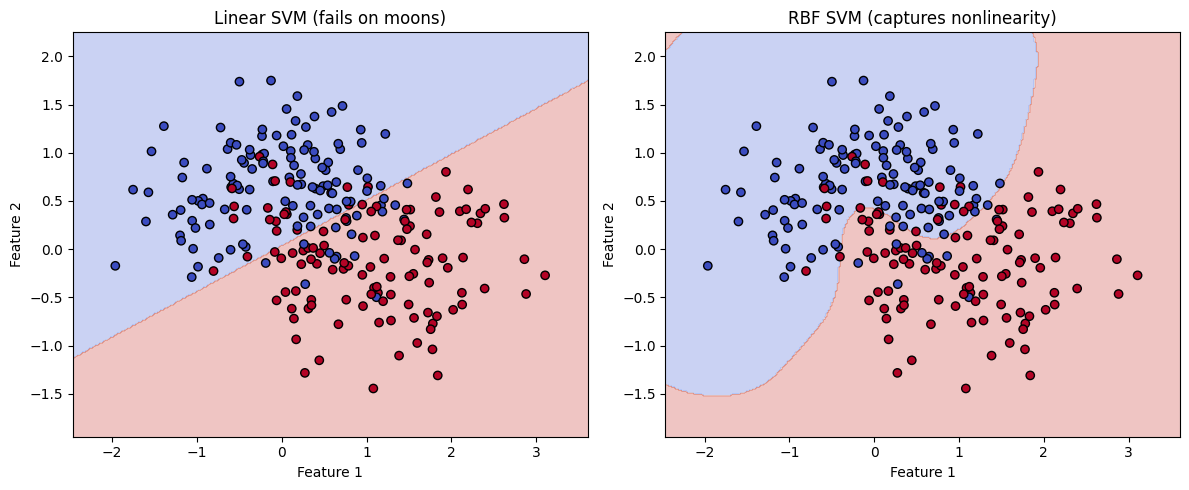

In [15]:
# 5. Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(linear_svm, X_train, y_train, axes[0], "Linear SVM (fails on moons)")
plot_decision_boundary(rbf_svm, X_train, y_train, axes[1], "RBF SVM (captures nonlinearity)")
plt.tight_layout()
plt.show()

In [ ]:
onto.save(file="/path/mlprov_estimator_bias_instances.owl")